# main.ipynb — Unified Pipeline

Integrates Prithvi-EO-2.0-300M and Prithvi-WxC end-to-end.

| Cell | Source | Description |
|------|--------|-------------|
| **0** | *(this repo)* | Setup & imports |
| **1** | `eo_data_installer.ipynb` | Authenticate & download EO dataset |
| **2** | `eo_extract_features.py` | Sliding window → encoder → save `mizuho_output/extracted_q_patch_*.pt` |
| **3** | `eo_attention_pooling.py` | Aggregate patches → Q `[1, 1024]` |
| **4** | `Prithvi-WxC/mycode.ipynb` Steps 1–5 | WxC pipeline → meteorological embedding `[B, N, 320]` |
| **5** | `Prithvi-WxC/mycode.ipynb` Step 6 | Cross-Modal MHA: fuse Q (EO) × K,V (WxC) → `[B, N, 1024]` |
| **6** | `Prithvi-WxC/mycode.ipynb` Step 7 | MLP Regression Head → Yield Prediction ẑ `[B, N]` |
| **7** | *(this repo)* | Training loop (loss / optimizer / adapter) |

---
## Cell 0: Setup & Imports

In [ ]:
import sys, os
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════════
#  TARGET SETTINGS 
# ════════════════════════════════════════════════════════════════════════════════

TARGET_GEOIDS = ["01001", "01003"]   # list of GEOID which wanna forcus
TARGET_YEAR   = 2020                  # year
# TARGET_CROP   = "CORN"                # "CORN" / "SOYBEANS" / "WHEAT" (etc.)

# ════════════════════════════════════════════════════════════════════════════════

# ── Submodule paths ────────────────────────────────────────────────────────────
REPO_ROOT   = Path("C:/Users/room208/mizuho")
EO_DIR      = REPO_ROOT / "Prithvi-EO-2.0-300M"
WXC_DIR     = REPO_ROOT / "Prithvi-WxC"
DATA_DIR    = REPO_ROOT / "data"
OUTPUT_DIR  = DATA_DIR   / "mizuho_output"

for p in [EO_DIR, WXC_DIR]:
    assert p.exists(), f"Submodule not found: {p}"
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Common imports ─────────────────────────────────────────────────────────────
import gc
import yaml
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── getting information of target centroids based on TARGET_GEOIDS  ─────────────────────────────────
_df_gaz = pd.read_csv(
    DATA_DIR / "2025_Gaz_counties_national.txt",
    sep="|", dtype={"GEOID": str}
)
_df_gaz.columns = _df_gaz.columns.str.strip()
_df_gaz = _df_gaz[["GEOID", "NAME", "USPS", "INTPTLAT", "INTPTLONG"]].rename(
    columns={"INTPTLAT": "lat", "INTPTLONG": "lon", "USPS": "state"}
)

df_target = _df_gaz[_df_gaz["GEOID"].isin(TARGET_GEOIDS)].reset_index(drop=True)
assert len(df_target) > 0, f"GEOID not found: {TARGET_GEOIDS}"

RESOLVED_GEOIDS = df_target["GEOID"].tolist()

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    gc.collect()
    torch.cuda.empty_cache()
print(f"Device  : {device}")
print(f"Target Counties : {list(zip(RESOLVED_GEOIDS, df_target['NAME'].tolist()))}")
print("Submodule paths OK.")

---
## Cell 1: EO Data Install
**Source:** `eo_data_installer.ipynb`  
Authenticates via `_netrc` and downloads HLS satellite data for US counties.

In [ ]:
import earthaccess
import rasterio
import tempfile
from tqdm import tqdm

earthaccess.login(strategy="netrc")

# Prithvi-EO uses 6 HLS bands: Blue, Green, Red, NIR, SWIR1, SWIR2
HLS_BANDS = ["B02", "B03", "B04", "B05", "B06", "B07"]

def download_hls_for_counties(
    df_counties: pd.DataFrame,
    output_dir: str,
    temporal: tuple = ("2020-01-01", "2020-01-31"),
    bbox_deg: float = 0.05,
    max_scenes_per_county: int = 1,
) -> dict:

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    results_map = {}
    failed = []

    for _, row in tqdm(df_counties.iterrows(), total=len(df_counties)):
        geoid = row["GEOID"]
        lat   = float(row["lat"])
        lon   = float(row["lon"])

        # Skip if already downloaded
        existing = list(out_dir.glob(f"{geoid}_*.tif"))
        if existing:
            results_map[geoid] = str(existing[0])
            continue

        bbox = (lon - bbox_deg, lat - bbox_deg,
                lon + bbox_deg, lat + bbox_deg)

        try:
            # Try S30 first, then L30
            for concept_id in ["C2021957657-LPCLOUD", "C2021957295-LPCLOUD"]:
                granules = earthaccess.search_data(
                    concept_id=concept_id,
                    temporal=temporal,
                    bounding_box=bbox,
                    count=max_scenes_per_county,
                )
                if granules:
                    break

            if not granules:
                failed.append(geoid)
                continue

            granule   = granules[0]
            all_urls  = [f for f in granule.data_links()]
            band_urls = [u for u in all_urls if any(f".{b}.tif" in u for b in HLS_BANDS)]

            if len(band_urls) != 6:
                print(f"  [WARN] {geoid}: unexpected band count ({len(band_urls)})")
                failed.append(geoid)
                continue

            with tempfile.TemporaryDirectory() as tmp:
                files        = earthaccess.download(band_urls, local_path=tmp)
                files_sorted = sorted(files)  # B02 → B03 → ... order

                out_path = out_dir / f"{geoid}_HLS.tif"
                datasets = [rasterio.open(f) for f in files_sorted]
                profile  = datasets[0].profile.copy()
                profile.update(count=6)

                with rasterio.open(out_path, "w", **profile) as dst:
                    for i, ds in enumerate(datasets, start=1):
                        dst.write(ds.read(1), i)
                for ds in datasets:
                    ds.close()

            results_map[geoid] = str(out_path)

        except Exception as e:
            print(f"  [WARN] {geoid}: {e}")
            failed.append(geoid)

    print(f"\nDone: {len(results_map)}/{len(df_counties)} counties")
    print(f"Failed: {len(failed)} counties")
    return results_map


# --Run: Download HLS data for the target counties defined in Cell 0
print(f"Downloading HLS data for {len(RESOLVED_GEOIDS)} counties: {RESOLVED_GEOIDS}")

hls_results = download_hls_for_counties(
    df_target,
    output_dir=DATA_DIR / "hls_counties",
    temporal=(f"{TARGET_YEAR}-01-01", f"{TARGET_YEAR}-12-31"),
)

for geoid, path in hls_results.items():
    print(f"  {geoid}: {path}")

100%|██████████| 2/2 [00:00<00:00, 2883.67it/s]


Done: 2/2 counties
Failed: 0 counties
  01001: C:\Users\room208\mizuho\data\hls_counties\01001_HLS.tif
  01003: C:\Users\room208\mizuho\data\hls_counties\01003_HLS.tif


---
## Cell 2: EO Feature Extraction
**Source:** `eo_extract_features.py`  
Sliding window over GeoTIFF → Prithvi-EO encoder → saves `mizuho_output/extracted_q_patch_*.pt`

In [ ]:
import re
import datetime
import rasterio
import yaml
from typing import List, Union
from einops import rearrange
from prithvi_mae import PrithviMAE

NO_DATA       = -9999
NO_DATA_FLOAT = 0.0001

# ── Config ─────────────────────────────────────────────────────────────────────
EO_CONFIG_PATH     = EO_DIR / "config.json"
EO_CHECKPOINT_PATH = EO_DIR / "Prithvi_EO_V2_300M.pt"

# ── DATA_FILES: Auto-generated from Cell 1's hls_results ────────────────────────────────
# hls_results = {geoid: tif_path} — Already obtained from Cell 1
DATA_FILES = {
    geoid: path for geoid, path in hls_results.items()
    if Path(path).exists()
}
assert len(DATA_FILES) > 0, "DATA_FILES is empty. Please run Cell 1 first."
print(f"Target TIF files ({len(DATA_FILES)} files):")
for geoid, f in DATA_FILES.items():
    print(f"  {geoid}: {f}")

# ── Helper functions ───────────────────────────────────────────────────────────
def read_geotiff(file_path: str):
    with rasterio.open(file_path) as src:
        img   = src.read()
        meta  = src.meta
        try:
            coords = src.lnglat()
        except:
            coords = None
    return img, meta, coords

def load_example(file_paths, mean, std, indices=None):
    imgs, metas, temporal_coords, location_coords = [], [], [], []
    for file in file_paths:
        img, meta, coords = read_geotiff(file)
        img = np.moveaxis(img, 0, -1)
        if indices is not None:
            img = img[..., indices]
        img = np.where(img == NO_DATA, NO_DATA_FLOAT, (img - mean) / std)
        imgs.append(img)
        metas.append(meta)
        if coords is not None:
            location_coords.append(coords)
        try:
            match = re.search(r'(\d{7,8}T\d{6})', file)
            if match:
                year       = int(match.group(1)[:4])
                julian_day = match.group(1).split('T')[0][4:]
                julian_day = int(julian_day) if len(julian_day) == 3 else \
                             datetime.datetime.strptime(julian_day, '%m%d').timetuple().tm_yday
                temporal_coords.append([year, julian_day])
            else:
                # If HLS timestamp cannot be extracted, substitute with TARGET_YEAR
                temporal_coords.append([TARGET_YEAR, 1])
        except Exception as e:
            temporal_coords.append([TARGET_YEAR, 1])
    imgs = np.stack(imgs, axis=0)
    imgs = np.moveaxis(imgs, -1, 0).astype("float32")
    imgs = np.expand_dims(imgs, axis=0)
    return imgs, temporal_coords, location_coords, metas

def run_model_extract(model, input_data, temporal_coords, location_coords, device, save_path):
    model.eval()
    with torch.no_grad():
        x             = input_data.to(device)
        features_list = model.forward_features(x, temporal_coords, location_coords)
        q_embedding   = features_list[-1]
        torch.save(q_embedding.cpu(), save_path)
        print(f"--> Saved Q to {save_path}  shape: {q_embedding.shape}")

# ── Load config & model (once only) ────────────────────────────────────────────
import json as _json
with open(EO_CONFIG_PATH, "r") as f:
    eo_config = yaml.safe_load(f)['pretrained_cfg']

bands      = eo_config['bands']
mean       = eo_config['mean']
std        = eo_config['std']
img_size   = eo_config['img_size']
coords_enc = eo_config['coords_encoding']

eo_config_single = dict(eo_config)
eo_config_single.update(coords_encoding=coords_enc, num_frames=1, in_chans=len(bands))
eo_model = PrithviMAE(**eo_config_single)
eo_model.to(device)

state_dict = torch.load(EO_CHECKPOINT_PATH, map_location=device, weights_only=True)
for k in list(state_dict.keys()):
    if 'pos_embed' in k:
        del state_dict[k]
eo_model.load_state_dict(state_dict, strict=False)
print(f"Loaded EO checkpoint from {EO_CHECKPOINT_PATH}")

# ── Sliding window per county → patch extraction ─────────────────────────────
# Output: mizuho_output/{geoid}/extracted_q_patch_*.pt
patch_dirs = {}  # {geoid: output_dir_path}

for geoid, tif_path in DATA_FILES.items():
    print(f"\n── {geoid} ({tif_path}) ──")

    # Output directory per county
    geoid_out = OUTPUT_DIR / geoid
    geoid_out.mkdir(parents=True, exist_ok=True)
    patch_dirs[geoid] = geoid_out

    # 1 county = 1 file = 1 timestep
    input_data, temporal_coords, location_coords, meta_data = load_example(
        [tif_path], mean=mean, std=std
    )

    # Dynamically adjust coords_encoding
    _coords_enc = dict(coords_enc)
    if len(temporal_coords) == 0 and 'time' in _coords_enc:
        _coords_enc.pop('time')
    if not len(location_coords) and 'location' in _coords_enc:
        _coords_enc.pop('location')

    # Pad & sliding window
    original_h, original_w = input_data.shape[-2:]
    pad_h = img_size - (original_h % img_size) if original_h % img_size != 0 else 0
    pad_w = img_size - (original_w % img_size) if original_w % img_size != 0 else 0
    input_data = np.pad(
        input_data, ((0,0),(0,0),(0,0),(0,pad_h),(0,pad_w)), mode="reflect"
    )

    batch   = torch.tensor(input_data, device="cpu")
    windows = batch.unfold(3, img_size, img_size).unfold(4, img_size, img_size)
    windows = rearrange(
        windows, "b c t h1 w1 h w -> (b h1 w1) c t h w", h=img_size, w=img_size
    )
    windows = torch.tensor_split(windows, windows.shape[0], dim=0)

    temporal_coords_t = torch.Tensor(temporal_coords).unsqueeze(0).to(device)
    location_coords_t = torch.Tensor(location_coords[0]).unsqueeze(0).to(device) \
                        if location_coords else None

    for i, x in enumerate(windows):
        save_path = str(geoid_out / f"extracted_q_patch_{i}.pt")
        run_model_extract(eo_model, x, temporal_coords_t, location_coords_t, device, save_path)

    print(f"  → {len(windows)} patches saved to {geoid_out}")

print(f"\nFeature extraction complete. Target counties: {list(patch_dirs.keys())}")


Target TIF files (2 files):
  01001: C:\Users\room208\mizuho\data\hls_counties\01001_HLS.tif
  01003: C:\Users\room208\mizuho\data\hls_counties\01003_HLS.tif
Loaded EO checkpoint from C:\Users\room208\mizuho\Prithvi-EO-2.0-300M\Prithvi_EO_V2_300M.pt

── 01001 (C:\Users\room208\mizuho\data\hls_counties\01001_HLS.tif) ──
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_0.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_1.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_2.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_3.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_4.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extra

---
## Cell 3: EO Attention Pooling → Q
**Source:** `eo_attention_pooling.py`  
Aggregates variable-length patch sequence into a single fixed-length Q tensor `[1, 1024]`.

In [ ]:
import glob

class PatchAttentionPooling(nn.Module):
    """
    Lightweight MLP attention over patch CLS tokens.
    Input : [B, N_patches, D]  →  Output: [B, D]
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.attention_net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.LayerNorm(embed_dim // 2),
            nn.Tanh(),
            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self, patch_embeddings):
        attn_scores  = self.attention_net(patch_embeddings)        # [B, N, 1]
        attn_weights = F.softmax(attn_scores, dim=1)               # [B, N, 1]
        pooled       = torch.bmm(attn_weights.transpose(1, 2), patch_embeddings)  # [B, 1, D]
        return pooled.squeeze(1), attn_weights


def aggregate_patches_for_county(pt_dir, embed_dim=1024):
    """Performs Attention Pooling on patches for 1 county and returns Q [1, 1024]"""
    patch_files = sorted(
        glob.glob(str(Path(pt_dir) / "extracted_q_patch_*.pt")),
        key=lambda p: int(Path(p).stem.split("_")[-1])
    )
    if not patch_files:
        raise FileNotFoundError(f"Patch files not found: {pt_dir}")

    patch_vectors = []
    for f in patch_files:
        q_tensor  = torch.load(f)     # [1, N_tokens, D]
        cls_token = q_tensor[:, 0, :] # [1, D]
        patch_vectors.append(cls_token)

    county_patches = torch.stack(patch_vectors, dim=1)  # [1, N_patches, D]

    model = PatchAttentionPooling(embed_dim=embed_dim)
    model.eval()
    with torch.no_grad():
        county_embedding, weights = model(county_patches)

    return county_embedding  # [1, 1024]


# ── Attention Pooling per county → save Q ──────────────────────────────────────
# patch_dirs generated in Cell 2: {geoid: Path}
q_save_paths = {}  # {geoid: q_pt_path}

for geoid, pt_dir in patch_dirs.items():
    q = aggregate_patches_for_county(pt_dir)
    save_path = pt_dir / "final_county_embedding_q.pt"
    torch.save(q, save_path)
    q_save_paths[geoid] = save_path
    print(f"  {geoid}: Q shape = {q.shape}  → {save_path}")

print(f"\nAttention Pooling complete. Q saved for: {list(q_save_paths.keys())}")


  01001: Q shape = torch.Size([1, 1024])  → C:\Users\room208\mizuho\data\mizuho_output\01001\final_county_embedding_q.pt
  01003: Q shape = torch.Size([1, 1024])  → C:\Users\room208\mizuho\data\mizuho_output\01003\final_county_embedding_q.pt

Attention Pooling complete. Q saved for: ['01001', '01003']


In [ ]:
# Cell 3のfinal_qの統計を確認
final_q = torch.load(q_save_paths["01001"], map_location="cpu")
print(f"EO Q stats:")
print(f"  mean={final_q.mean():.4f}  std={final_q.std():.4f}  max={final_q.max():.4f}  min={final_q.min():.4f}")

EO Q stats:
  mean=0.0254  std=0.9081  max=26.6471  min=-3.6560


---
## Cell 4: WxC Weather Model Pipeline
**Source:** `Prithvi-WxC/mycode.ipynb` Steps 1–5  
Loads MERRA-2 data → Prithvi-WxC → global feature map → spatial query at county centroids → meteorological embedding `[B, N, 320]`.

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
from huggingface_hub import hf_hub_download
from PrithviWxC.model import PrithviWxC
from PrithviWxC.dataloaders.merra2 import (
    Merra2Dataset, preproc,
    input_scalers, output_scalers, static_input_scalers,
)

import gc
try:
    del eo_model
except NameError:
    pass
torch.cuda.empty_cache()
gc.collect()
print(f"GPU空き: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ── Config ─────────────────────────────────────────────────────────────────────
surface_vars        = ["EFLUX","GWETROOT","HFLUX","LAI","LWGAB","LWGEM","LWTUP",
                       "PS","QV2M","SLP","SWGNT","SWTNT","T2M","TQI","TQL","TQV",
                       "TS","U10M","V10M","Z0M"]
static_surface_vars = ["FRACI","FRLAND","FROCEAN","PHIS"]
vertical_vars       = ["CLOUD","H","OMEGA","PL","QI","QL","QV","T","U","V"]
levels              = [34,39,41,43,44,45,48,51,53,56,63,68,71,72]
padding             = {"level": [0,0], "lat": [0,-1], "lon": [0,0]}
lead_times          = [18]
input_times         = [-6]
positional_encoding = "fourier"

merra_dir = WXC_DIR / "data" / "merra-2"
clim_dir  = WXC_DIR / "data" / "climatology"

# ── Step 1: Stacked input tensor ───────────────────────────────────────────────
def build_stacked_input(batch: dict) -> dict:
    Xt = batch["x"]
    S  = batch["static"]
    C  = batch.get("climate", None)
    assert C is not None, "climate key missing from batch"
    return {"Xt": Xt, "S": S, "C": C}

# ── Step 2: County centroids ───────────────────────────────────────────────────
def prepare_county_centroids(county_ids, lats, lons) -> dict:
    return {
        "county_ids": county_ids,
        "lats": torch.tensor(lats, dtype=torch.float32),
        "lons": torch.tensor(lons, dtype=torch.float32),
    }

def load_centroids_from_census_gazetteer(path: str) -> dict:
    df = pd.read_csv(path, sep="|", dtype={"GEOID": str}, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    return prepare_county_centroids(
        df["GEOID"].tolist(),
        df["INTPTLAT"].tolist(),
        df["INTPTLONG"].tolist(),
    )

# ── Step 3: Global feature map via Prithvi-WxC (encoder only) ─────────────────
def get_global_feature_map(model, batch, device):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)

    with torch.no_grad():
        model.eval()

        x_rescaled = (batch["x"] - model.input_scalers_mu) / (
            model.input_scalers_sigma + model.input_scalers_epsilon
        )
        x_rescaled = x_rescaled.flatten(1, 2)

        x_pos      = model.fourier_pos_encoding(batch["static"])
        x_static   = (batch["static"][:, 2:] - model.static_input_scalers_mu[:, 3:]) / (
            model.static_input_scalers_sigma[:, 3:] + model.static_input_scalers_epsilon
        )
        climate_scaled = (
            batch["climate"] - model.input_scalers_mu.view(1, -1, 1, 1)
        ) / (model.input_scalers_sigma.view(1, -1, 1, 1) + model.input_scalers_epsilon)

        x_emb      = model.patch_embedding(x_rescaled)
        static_emb = model.patch_embedding_static(
            torch.cat((x_static, climate_scaled), dim=1)
        )
        static_emb += x_pos
        x_emb      = model.to_patching(x_emb)
        static_emb = model.to_patching(static_emb)

        time_enc   = model.time_encoding(batch["input_time"], batch["lead_time"])
        tokens     = x_emb + static_emb + time_enc  # [B, G, L, D]

        # encoder のみ（decoderを通さない）
        x_encoded  = model.encoder(tokens)           # [B, G, L, D]

        # [B, G, L, D] → [B, D, lat, lon]
        B          = x_encoded.shape[0]
        G0, G1     = model.global_shape_mu           # 45, 72
        L0, L1     = model.local_shape_mu            # 4, 4
        D          = model.embed_dim                 # 160

        x          = x_encoded.view(B, G0, G1, L0, L1, D)
        x          = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        feature_map = x.view(B, D, G0 * L0, G1 * L1)  # [1, 160, 180, 288]

    return feature_map

# ── Step 4: Spatial query (bilinear interpolation at county centroids) ─────────
def spatial_query(feature_map, C, centroids, lat_grid, lon_grid):
    lats      = centroids["lats"]
    lons      = centroids["lons"]
    norm_lats = 2.0 * (lats - lat_grid.min()) / (lat_grid.max() - lat_grid.min()) - 1.0
    norm_lons = 2.0 * (lons - lon_grid.min()) / (lon_grid.max() - lon_grid.min()) - 1.0
    grid      = torch.stack([norm_lons, norm_lats], dim=-1)
    grid      = grid.unsqueeze(0).unsqueeze(0).expand(feature_map.shape[0], 1, -1, -1)
    county_weather_token     = F.grid_sample(
        feature_map, grid, mode="bilinear", align_corners=True
    ).squeeze(2).permute(0, 2, 1)
    local_climatology_vector = F.grid_sample(
        C, grid, mode="bilinear", align_corners=True
    ).squeeze(2).permute(0, 2, 1)
    return county_weather_token, local_climatology_vector

# ── Step 5: Meteorological embedding ──────────────────────────────────────────
def build_meteorological_embedding(county_weather_token, local_climatology_vector):
    return torch.cat([county_weather_token, local_climatology_vector], dim=-1)

# ── Load dataset & batch ───────────────────────────────────────────────────────
dataset = Merra2Dataset(
    time_range=("2020-01-01T00:00:00", "2020-01-02T05:59:59"),
    lead_times=lead_times,
    input_times=input_times,
    data_path_surface=merra_dir,
    data_path_vertical=merra_dir,
    climatology_path_surface=clim_dir,
    climatology_path_vertical=clim_dir,
    surface_vars=surface_vars,
    static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars,
    levels=levels,
    positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "No valid data found"

data  = next(iter(dataset))
batch = preproc([data], padding)

# ── Scalers ────────────────────────────────────────────────────────────────────
in_mu,     in_sig    = input_scalers(surface_vars, vertical_vars, levels,
                           clim_dir/"musigma_surface.nc",
                           clim_dir/"musigma_vertical.nc")
output_sig            = output_scalers(surface_vars, vertical_vars, levels,
                           clim_dir/"anomaly_variance_surface.nc",
                           clim_dir/"anomaly_variance_vertical.nc")
static_mu, static_sig = static_input_scalers(clim_dir/"musigma_surface.nc",
                           static_surface_vars)

# ── Load WxC model ─────────────────────────────────────────────────────────────
with open(WXC_DIR / "data" / "config.yaml") as f:
    wxc_config = yaml.safe_load(f)
p = wxc_config["params"]

wxc_model = PrithviWxC(
    in_channels=p["in_channels"],
    input_size_time=p["input_size_time"],
    in_channels_static=p["in_channels_static"],
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=p["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=p["static_input_scalers_epsilon"],
    output_scalers=output_sig**0.5,
    n_lats_px=p["n_lats_px"],
    n_lons_px=p["n_lons_px"],
    patch_size_px=p["patch_size_px"],
    mask_unit_size_px=p["mask_unit_size_px"],
    mask_ratio_inputs=0.0,
    mask_ratio_targets=0.0,
    embed_dim=p["embed_dim"],
    n_blocks_encoder=p["n_blocks_encoder"],
    n_blocks_decoder=p["n_blocks_decoder"],
    mlp_multiplier=p["mlp_multiplier"],
    n_heads=p["n_heads"],
    dropout=p["dropout"],
    drop_path=p["drop_path"],
    parameter_dropout=p["parameter_dropout"],
    residual="climate",
    masking_mode="global",
    encoder_shifting=True,
    decoder_shifting=True,
    positional_encoding=positional_encoding,
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)

weights_path = WXC_DIR / "data" / "weights" / "prithvi.wxc.2300m.v1.pt"
state_dict   = torch.load(weights_path, weights_only=False)
state_dict   = state_dict.get("model_state", state_dict)
wxc_model.load_state_dict(state_dict, strict=True)
wxc_model    = wxc_model.to(device)

# ── Steps 3 → 5 ───────────────────────────────────────────────────────────────
feature_map = get_global_feature_map(wxc_model, batch, device)
print("feature_map shape:", feature_map.shape)   # [1, 160, 180, 288]
print(f"  mean={feature_map.mean():.4f}  std={feature_map.std():.4f}")

lat_grid = torch.linspace(-90,  90,  feature_map.shape[-2])
lon_grid = torch.linspace(-180, 180, feature_map.shape[-1])

# C_tensorも正規化
C_tensor = (batch["climate"].to(device) - wxc_model.input_scalers_mu.view(1, -1, 1, 1)) / (
    wxc_model.input_scalers_sigma.view(1, -1, 1, 1) + wxc_model.input_scalers_epsilon
)

centroids = {
    "county_ids": df_target["GEOID"].tolist(),
    "lats": torch.tensor(df_target["lat"].tolist(), dtype=torch.float32).to(device),
    "lons": torch.tensor(df_target["lon"].tolist(), dtype=torch.float32).to(device),
}
print(f"対象郡数 N = {len(centroids['county_ids'])}  {centroids['county_ids']}")

county_weather_token, local_climatology_vector = spatial_query(
    feature_map, C_tensor, centroids, lat_grid, lon_grid
)
print("county_weather_token shape:", county_weather_token.shape)
print(f"  mean={county_weather_token.mean():.4f}  std={county_weather_token.std():.4f}")

met_embedding = build_meteorological_embedding(county_weather_token, local_climatology_vector)
print("met_embedding shape:", met_embedding.shape)   # [1, N, 320]
print(f"  mean={met_embedding.mean():.4f}  std={met_embedding.std():.4f}")

del wxc_model
torch.cuda.empty_cache()
gc.collect()

GPU空き: 22.9 GB


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.48 GiB. GPU 0 has a total capacity of 23.99 GiB of which 9.35 GiB is free. Of the allocated memory 12.87 GiB is allocated by PyTorch, and 162.29 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

---
## Cell 5: Cross-Modal Multi-Head Attention → Fused Embedding
**Source:** `Prithvi-WxC/mycode.ipynb` Step 6  

| Role | Source | Shape |
|------|--------|-------|
| **Q** | Prithvi-EO (Cell 3) | `[B, N, 1024]` |
| **K = V** | Prithvi-WxC met embedding (Cell 4) | `[B, N, 320]` |

K/V are projected from 320 → 1024 before MHA. Residual + LayerNorm applied.

In [ ]:
class CrossModalAttention(nn.Module):
    """
    Q  = EO embedding      [B, N, D_eo=1024]
    K  = V = met_embedding [B, N, D_met=320]
    Projects K,V → D_eo, runs MHA, applies residual + LayerNorm.
    Output: [B, N, D_eo]
    """
    def __init__(self, d_eo: int, d_met: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.kv_proj = nn.Linear(d_met, d_eo)
        self.attn    = nn.MultiheadAttention(
            embed_dim=d_eo, num_heads=n_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm = nn.LayerNorm(d_eo)

    def forward(self, q: torch.Tensor, kv: torch.Tensor) -> torch.Tensor:
        kv_proj     = self.kv_proj(kv)
        attn_out, _ = self.attn(q, kv_proj, kv_proj)
        return self.norm(q + attn_out)  # [B, N, D_eo]


# ── Stack Q for all counties in RESOLVED_GEOIDS order to [1, N, 1024] ───────────────
eo_q_list = []
for geoid in RESOLVED_GEOIDS:
    q = torch.load(q_save_paths[geoid], map_location=device)  # [1, 1024]
    eo_q_list.append(q)

eo_q = torch.stack(eo_q_list, dim=1)  # [1, N, 1024]
print(f"EO Q (all counties) : {eo_q.shape}")

# ── Reorder met_embedding in RESOLVED_GEOIDS order ──────────────────────────
geoid_to_met_idx = {g: idx for idx, g in enumerate(centroids["county_ids"])}
met_indices = [geoid_to_met_idx[g] for g in RESOLVED_GEOIDS]
met_emb = met_embedding[:, met_indices, :]  # [1, N, 320]
print(f"Met embedding       : {met_emb.shape}")

# ── Cross-Modal Attention (batch process all counties) ────────────────────────────────
D_eo    = eo_q.shape[-1]      # 1024
D_met   = met_emb.shape[-1]   # 320
n_heads = 8                   # 1024 % 8 == 0 ✓

cross_attn = CrossModalAttention(d_eo=D_eo, d_met=D_met, n_heads=n_heads).to(device)
fused = cross_attn(eo_q, met_emb)  # [1, N, 1024]

print("-" * 40)
print(f"Q  (EO)         : {eo_q.shape}")    # [1, N, 1024]
print(f"K=V (WxC)       : {met_emb.shape}") # [1, N, 320]
print(f"Fused embedding : {fused.shape}")   # [1, N, 1024]


EO Q (all counties) : torch.Size([1, 2, 1024])
Met embedding       : torch.Size([1, 2, 2720])
----------------------------------------
Q  (EO)         : torch.Size([1, 2, 1024])
K=V (WxC)       : torch.Size([1, 2, 2720])
Fused embedding : torch.Size([1, 2, 1024])


In [ ]:
print(f"feature_map shape: {feature_map.shape}")


feature_map shape: torch.Size([1, 2560, 180, 288])


torch.Size([1, 2, 2720])


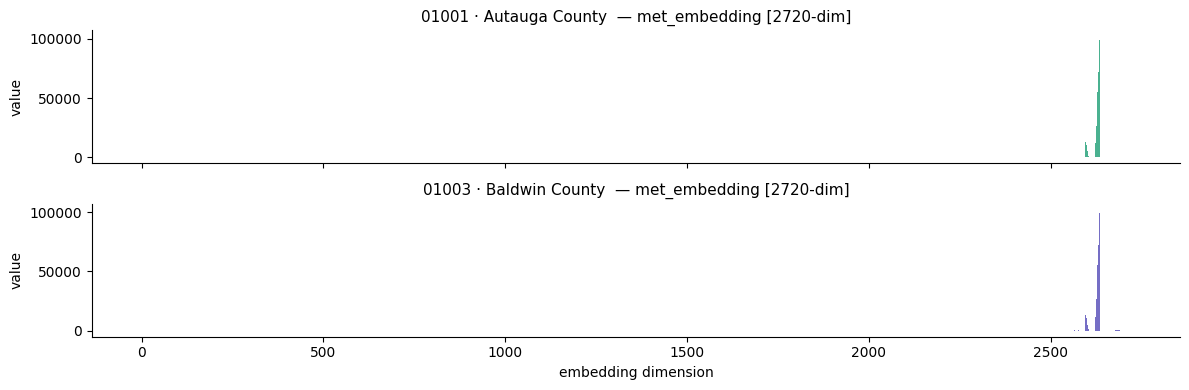

In [ ]:
# met_embeddingの次元を確認
print(met_embedding.shape)  # [1, 2, 2720] になっているはず

# ── 可視化コードの修正 ──────────────────────────────────
met = met_embedding[0].detach().cpu().numpy()  # [2, 2720]
n_dim = met.shape[1]  # 320ではなく実際の次元数を使う

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for i, (ax, geoid, name) in enumerate(zip(axes, RESOLVED_GEOIDS, df_target["NAME"].tolist())):
    ax.bar(range(n_dim), met[i], color=["#1D9E75","#534AB7"][i], width=1.0, alpha=0.8)
    ax.set_ylabel("value")
    ax.set_title(f"{geoid} · {name}  — met_embedding [{n_dim}-dim]", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
axes[-1].set_xlabel("embedding dimension")
plt.tight_layout()
plt.show()

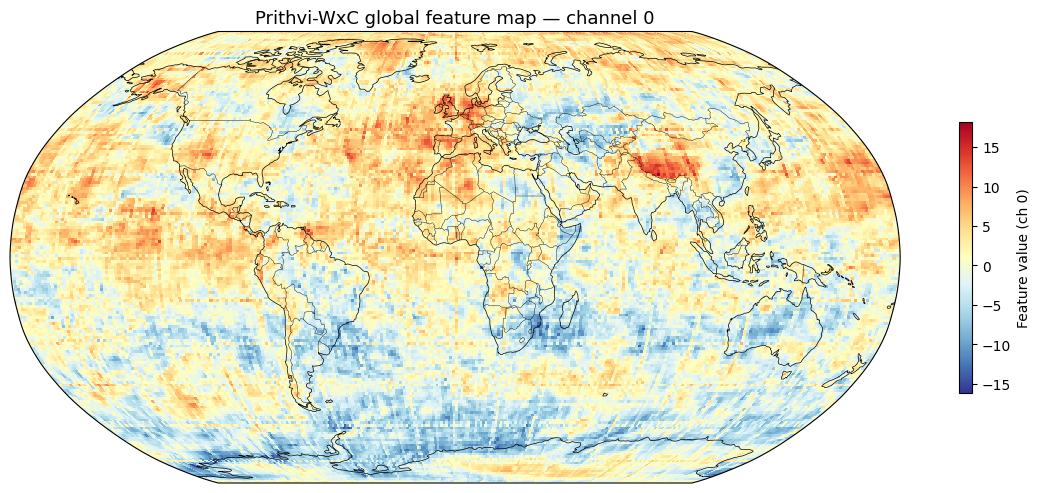

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (320,) and arg 1 with shape (2720,).

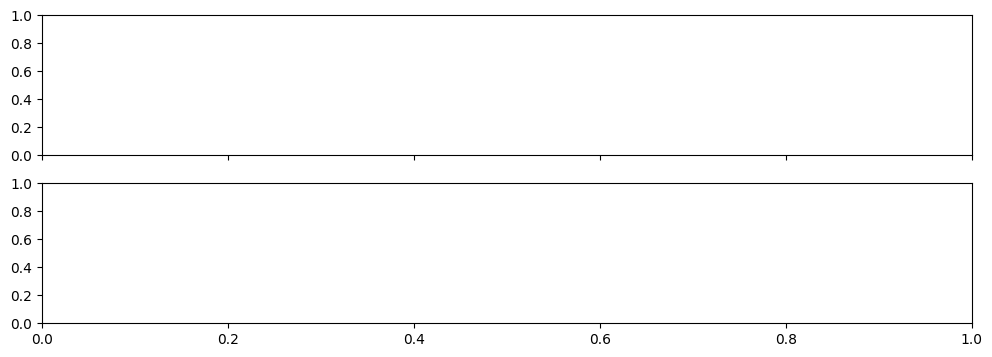

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ═══════════════════════════════════════════════
# 1. feature_map — 全球気象特徴マップ (Cell 4)
# ═══════════════════════════════════════════════
# channel 0 だけ可視化（160チャンネルの最初の1枚）
fm = feature_map[0, 0].detach().cpu().numpy()  # [360, 576]

fig, ax = plt.subplots(1, 1, figsize=(12, 5),
                       subplot_kw={"projection": ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3)

lons = np.linspace(-180, 180, fm.shape[1])
lats = np.linspace(-90,   90, fm.shape[0])
im = ax.pcolormesh(lons, lats, fm,
                   transform=ccrs.PlateCarree(),
                   cmap="RdYlBu_r", shading="auto")
plt.colorbar(im, ax=ax, shrink=0.6, label="Feature value (ch 0)")
ax.set_title("Prithvi-WxC global feature map — channel 0", fontsize=13)
plt.tight_layout()
plt.show()



# ═══════════════════════════════════════════════
# 2. met_embedding — 2郡の気象埋め込み (Cell 4-5)
# ═══════════════════════════════════════════════
met = met_embedding[0].detach().cpu().numpy()  # [2, 320]

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for i, (ax, geoid, name) in enumerate(zip(axes, RESOLVED_GEOIDS, df_target["NAME"].tolist())):
    ax.bar(range(320), met[i], color=["#1D9E75","#534AB7"][i], width=1.0, alpha=0.8)
    ax.set_ylabel("value")
    ax.set_title(f"{geoid} · {name}  — met_embedding [320-dim]", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
axes[-1].set_xlabel("embedding dimension")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════
# 3. county_weather_token — 郡の位置をマップ上にプロット
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-100, -80, 28, 38], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES,     linewidth=0.8)
ax.add_feature(cfeature.COASTLINE,  linewidth=0.8)
ax.add_feature(cfeature.LAND,       facecolor="#F1EFE8")
ax.add_feature(cfeature.OCEAN,      facecolor="#E1F5EE")

# 郡のcentroidをプロット
lats_c = df_target["lat"].tolist()
lons_c = df_target["lon"].tolist()
names  = df_target["NAME"].tolist()
tokens = county_weather_token[0].detach().cpu().numpy()  # [2, 160]
vals   = tokens[:, 0]  # channel 0 の値で色付け

sc = ax.scatter(lons_c, lats_c, c=vals, s=200,
                cmap="RdYlBu_r", transform=ccrs.PlateCarree(),
                edgecolors="white", linewidths=1.5, zorder=5)
plt.colorbar(sc, ax=ax, shrink=0.7, label="Weather token value (ch 0)")

for lon, lat, name in zip(lons_c, lats_c, names):
    ax.text(lon + 0.3, lat + 0.2, name, fontsize=9,
            transform=ccrs.PlateCarree())

ax.set_title("County weather tokens — Alabama (bilinear interpolation from WxC)", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
print("county_weather_token stats:")
print(f"  mean={county_weather_token.mean():.4f}  std={county_weather_token.std():.4f}  max={county_weather_token.max():.4f}")

print("local_climatology_vector stats:")
print(f"  mean={local_climatology_vector.mean():.4f}  std={local_climatology_vector.std():.4f}  max={local_climatology_vector.max():.4f}")

county_weather_token stats:
  mean=6477.2485  std=20641.7754  max=101750.6094
local_climatology_vector stats:
  mean=6488.7852  std=20702.8438  max=102092.5234


---
## Cell 6: MLP Regression Head → Yield Prediction ẑ
**Source:** `Prithvi-WxC/mycode.ipynb` Step 7  

Passes fused vector through MLP to output per-county yield prediction value ẑ.

```
[B, N, 1024] → Linear(1024→256) → GELU → Linear(256→128) → GELU → Linear(128→1) → [B, N]
```

In [ ]:
class MLPRegressionHead(nn.Module):
    """
    Input : [B, N, D_eo=1024]
    Output: [B, N]  — per-county yield prediction ẑ
    """
    def __init__(self, d_in: int, hidden_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_in, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x).squeeze(-1)  # [B, N]


# ── Initialization ─────────────────────────────────────────────────────────────────────
mlp_head = MLPRegressionHead(d_in=D_eo).to(device)

# ── Inference (pre-training verification) ─────────────────────────────────────────────────
with torch.no_grad():
    y_hat = mlp_head(fused)  # [B, N]

print("-" * 40)
print("Fused input     :", fused.shape)   # [B, N, 1024]
print("Yield pred ẑ    :", y_hat.shape)   # [B, N]
print("Sample values   :", y_hat[0, :5])

----------------------------------------
Fused input     : torch.Size([1, 2, 1024])
Yield pred ẑ    : torch.Size([1, 2])
Sample values   : tensor([-0.0372, -0.0858], device='cuda:0')


# OUTPUT

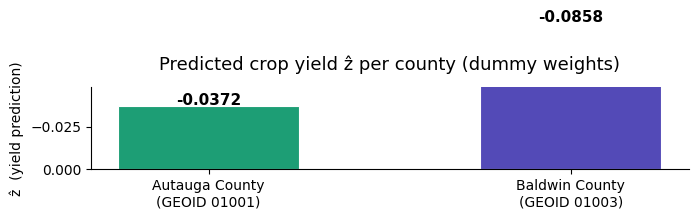

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ────────────────────────────────────────────────────────────────────
geoids = RESOLVED_GEOIDS                          # ['01001', '01003']
names  = df_target["NAME"].tolist()               # ['Autauga County', 'Baldwin County']
yields = y_hat[0].detach().cpu().numpy()          # [0.0403, 0.0437]

# ── Bar Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#1D9E75", "#534AB7"]
bars   = ax.bar(names, yields, color=colors, width=0.5, edgecolor="white", linewidth=0.8)

# Display values above each bar
for bar, val in zip(bars, yields):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Predicted crop yield ẑ per county (dummy weights)", fontsize=13, pad=12)
ax.set_ylabel("ẑ  (yield prediction)")
ax.set_ylim(0, max(yields) * 1.3)
ax.spines[["top", "right"]].set_visible(False)

# Append GEOID to X-axis labels
ax.set_xticks(range(len(names)))
ax.set_xticklabels([f"{n}\n(GEOID {g})" for n, g in zip(names, geoids)], fontsize=10)

plt.tight_layout()
plt.show()